# Freesound clustering with interactive playback

This notebook follows a simple flow:

1. Import libraries and define descriptor mappings
2. Define download helpers
3. Optionally download example sounds
4. Define clustering and visualization helpers
5. Configure the interactive plotting backend
6. Run clustering and inspect the PCA projection interactively

In [30]:
import os
from pathlib import Path
from typing import Any
import platform
import subprocess

import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
import freesound as fs
from scipy.cluster.vq import kmeans, whiten

descriptors = [ 'lowlevel.spectral_centroid.mean',
                'lowlevel.spectral_contrast.mean',
                'lowlevel.dissonance.mean',
                'lowlevel.hfc.mean',
                'lowlevel.mfcc.mean',
                'sfx.logattacktime.mean',
                'sfx.inharmonicity.mean']

# Mapping of descriptors
descriptorMapping = { 0: 'lowlevel.spectral_centroid.mean',
                      1: 'lowlevel.dissonance.mean',
                      2: 'lowlevel.hfc.mean',
                      3: 'sfx.logattacktime.mean',
                      4: 'sfx.inharmonicity.mean',
                      5: 'lowlevel.spectral_contrast.mean.0',
                      6: 'lowlevel.spectral_contrast.mean.1',
                      7: 'lowlevel.spectral_contrast.mean.2',
                      8: 'lowlevel.spectral_contrast.mean.3',
                      9: 'lowlevel.spectral_contrast.mean.4',
                      10: 'lowlevel.spectral_contrast.mean.5',
                      11: 'lowlevel.mfcc.mean.0',
                      12: 'lowlevel.mfcc.mean.1',
                      13: 'lowlevel.mfcc.mean.2',
                      14: 'lowlevel.mfcc.mean.3',
                      15: 'lowlevel.mfcc.mean.4',
                      16: 'lowlevel.mfcc.mean.5'
                    }

## Download helpers

These functions download Freesound previews and descriptor JSON files.

In [31]:
def download_sounds_freesound(queryText = "", tag=None, duration=None, API_Key = "", outputDir = "", topNResults = 5, featureExt = '.json'):
  """
  This function downloads sounds and their descriptors from freesound using the queryText and the 
  tag specified in the input. Additionally, you can also specify the duration range to filter sounds 
  based on duration.
  
  Inputs:
        (Input parameters marked with a * are optional)
        queryText (string): query text for the sounds (eg. "violin", "trumpet", "cello", "bassoon" etc.)
        tag* (string): tag to be used for filtering the searched sounds. (eg. "multisample",  
                       "single-note" etc.)
        duration* (tuple): min and the max duration (seconds) of the sound to filter, eg. (0.2,15)
        API_Key (string): your api key, which you can obtain from : www.freesound.org/apiv2/apply/
        outputDir (string): path to the directory where you want to store the sounds and their 
                            descriptors
        topNResults (integer): number of results(sounds) that you want to download 
        featureExt (string): file extension for storing sound descriptors
  output:
        This function downloads sounds and descriptors, and then stores them in outputDir. In 
        outputDir it creates a directory of the same name as that of the queryText. In this 
        directory outputDir/queryText it creates a directory for every sound with the name 
        of the directory as the sound id. Additionally, this function also dumps a text file 
        containing sound-ids and freesound links for all the downloaded sounds in the outputDir. 
        NOTE: If the directory outputDir/queryText exists, it deletes the existing contents 
        and stores only the sounds from the current query. 
  """ 
  
  # Checking for the compulsory input parameters
  if queryText == "":
    print("\n")
    print("Provide a query text to search for sounds")
    return -1

  if API_Key == "":
    print("\n")
    print("You need a valid freesound API key to be able to download sounds.")
    print("Please apply for one here: www.freesound.org/apiv2/apply/")
    print("\n")
    return -1

  if outputDir == "" or not os.path.exists(outputDir):
    print("\n")
    print("Please provide a valid output directory. This will be the root directory for storing sounds and descriptors")
    return -1    

  # Setting up the Freesound client and the authentication key
  fsClnt = fs.FreesoundClient()
  fsClnt.set_token(API_Key,"token")  

  # Creating a duration filter string that the Freesound API understands
  if duration and type(duration) == tuple:
    flt_dur = f" duration:[{str(duration[0])}" + " TO " + str(duration[1]) + "]"
  else:
    flt_dur = ""

  if tag and type(tag) == str:
    flt_tag = "tag:"+tag
  else:
    flt_tag = ""

  # Querying Freesound
  page_size = 30
  if not flt_tag + flt_dur == "":
    qRes = fsClnt.text_search(query=queryText ,filter = flt_tag + flt_dur,sort="score", fields="id,name,previews,username,url,analysis", descriptors=','.join(descriptors), page_size=page_size, normalized=1)
  else:
    qRes = fsClnt.text_search(query=queryText ,sort="score",fields="id,name,previews,username,url,analysis", descriptors=','.join(descriptors), page_size=page_size, normalized=1)

  outDir2 = os.path.join(outputDir, queryText)
  if os.path.exists(outDir2):             # If the directory exists, it deletes it and starts fresh
      os.system("rm -r " + outDir2)
  os.mkdir(outDir2)

  pageNo = 1
  sndCnt = 0
  indCnt = 0
  totalSnds = min(qRes.count,200)   # System quits after trying to download after 200 times

  # Creating directories to store output and downloading sounds and their descriptors
  downloadedSounds = []
  while(1):
    if indCnt >= totalSnds:
      print("Not able to download required number of sounds. Either there are not enough search results on freesound for your search query and filtering constraints or something is wrong with this script.")
      break
    sound = qRes[indCnt - ((pageNo-1)*page_size)]
    print("Downloading mp3 preview and descriptors for sound with id: %s"%str(sound.id))
    outDir1 = os.path.join(outputDir, queryText, str(sound.id))
    if os.path.exists(outDir1):
      os.system("rm -r " + outDir1)
    os.system("mkdir " + outDir1)

    mp3Path = os.path.join(outDir1,  str(sound.previews.preview_lq_mp3.split("/")[-1]))
    ftrPath = mp3Path.replace('.mp3', featureExt)

    try:

      fs.FSRequest.retrieve(sound.previews.preview_hq_mp3, fsClnt, mp3Path)
      # Initialize a dictionary to store descriptors
      features = {}
      # Obtaining all the descriptors
      for desc in descriptors:
        features[desc]=[]
        features[desc].append(eval("sound.analysis."+desc))

      # Once we have all the descriptors, store them in a json file
      json.dump(features, open(ftrPath,'w'))
      sndCnt+=1
      downloadedSounds.append([str(sound.id), sound.url])

    except:
      if os.path.exists(outDir1):
        os.system("rm -r " + outDir1)

    indCnt +=1

    if indCnt%page_size==0:
      qRes = qRes.next_page()
      pageNo+=1

    if sndCnt>=topNResults:
      break
  # Dump the list of files and Freesound links
  fid = open(os.path.join(outDir2, queryText+'_SoundList.txt'), 'w')
  for elem in downloadedSounds:
    fid.write('\t'.join(elem)+'\n')
  fid.close()

In [ ]:
import os
from dotenv import load_dotenv

# Optional: download example sounds for a few instrument classes
output_dir = Path('descSounds')
output_dir.mkdir(exist_ok=True)

# Load API key from .env file (copy .env.example → .env and fill in your key)
load_dotenv()
api_key = os.environ.get("FREESOUND_API_KEY")
if not api_key:
    raise EnvironmentError(
        "FREESOUND_API_KEY not set. "
        "Create a .env file with FREESOUND_API_KEY=your_key (see .env.example)."
    )

download_sounds_freesound(queryText='cello', API_Key=api_key, outputDir=str(output_dir), topNResults=20, duration=(0, 5), tag='single-note')
download_sounds_freesound(queryText='violin', API_Key=api_key, outputDir=str(output_dir), topNResults=20, duration=(0, 5), tag='single-note')
download_sounds_freesound(queryText='bassoon', API_Key=api_key, outputDir=str(output_dir), topNResults=20, duration=(0, 5), tag='single-note')
download_sounds_freesound(queryText='guitar', API_Key=api_key, outputDir=str(output_dir), topNResults=20, duration=(0, 5), tag='single-note')
download_sounds_freesound(queryText='trumpet', API_Key=api_key, outputDir=str(output_dir), topNResults=20, duration=(0, 5), tag='single-note')

FreesoundException: <FreesoundException: code=504, detail="Gateway Time-out">

## Analysis helpers

These utilities handle descriptor conversion, clustering, PCA projection, and interactive plotting.

In [ ]:
def convFtrDict2List(ftrDict):
  """
  This function converts descriptor dictionary to an np.array. The order in the numpy array (indices) 
  are same as those mentioned in descriptorMapping dictionary.
  
  Input: 
    ftrDict (dict): dictionary containing descriptors downloaded from the freesound
  Output: 
    ftr (np.ndarray): Numpy array containing the descriptors for processing later on
  """
  ftr = []
  for key in range(len(descriptorMapping.keys())):
    try:
      ftrName, ind = '.'.join(descriptorMapping[key].split('.')[:-1]), int(descriptorMapping[key].split('.')[-1])
      ftr.append(ftrDict[ftrName][0][ind])
    except:
      ftr.append(ftrDict[descriptorMapping[key]][0])
  return np.array(ftr)

def fetchDataDetails(inputDir, descExt = '.json'):
  """
  This function is used by other functions to obtain the information regarding the directory structure 
  and the location of descriptor files for each sound 
  """
  dataDetails = {}
  for path, dname, fnames  in os.walk(inputDir):
    for fname in fnames:
      if descExt in fname.lower():
        remain, rname, cname, sname = path.split('/')[:-3], path.split('/')[-3], path.split('/')[-2], path.split('/')[-1]
        if cname not in dataDetails:
          dataDetails[cname]={}
        fDict = json.load(open(os.path.join('/'.join(remain), rname, cname, sname, fname),'r'))
        dataDetails[cname][sname]={'file': fname, 'feature':fDict}
  return dataDetails

def cluster_sounds(targetDir, nCluster = -1, descInput=[]):
  """
  This function clusters all the sounds in targetDir using kmeans clustering.
  
  Input:
    targetDir (string): Directory where sound descriptors are stored (all the sounds in this 
                        directory will be used for clustering)
    nCluster (int): Number of clusters to be used for kmeans clustering.
    descInput (list) : List of indices of the descriptors to be used for similarity/distance 
                       computation (see descriptorMapping)
  Output:
    Prints the class of each cluster (computed by a majority vote), number of sounds in each 
    cluster and information (sound-id, sound-class and classification decision) of the sounds 
    in each cluster. Optionally, you can uncomment the return statement to return the same data.
  """
  
  dataDetails = fetchDataDetails(targetDir)
  
  ftrArr = []
  infoArr = []
  
  if nCluster ==-1:
    nCluster = len(dataDetails.keys())
  for cname in dataDetails.keys():
    #iterating over sounds
    for sname in dataDetails[cname].keys():
      ftrArr.append(convFtrDict2List(dataDetails[cname][sname]['feature'])[descInput])
      infoArr.append([sname, cname])
  
  ftrArr = np.array(ftrArr)
  infoArr = np.array(infoArr)
  
  ftrArrWhite = whiten(ftrArr)
  centroids, distortion = kmeans(ftrArrWhite, nCluster)
  clusResults = -1*np.ones(ftrArrWhite.shape[0])
  
  for ii in range(ftrArrWhite.shape[0]):
    diff = centroids - ftrArrWhite[ii,:]
    diff = np.sum(np.power(diff,2), axis = 1)
    indMin = np.argmin(diff)
    clusResults[ii] = indMin
  
  ClusterOut = []
  classCluster = []
  globalDecisions = []  
  for ii in range(nCluster):
    ind = np.where(clusResults==ii)[0]
    freqCnt = []
    for elem in infoArr[ind,1]:
      freqCnt.append(infoArr[ind,1].tolist().count(elem))
    indMax = np.argmax(freqCnt)
    classCluster.append(infoArr[ind,1][indMax])
    
    print("\n(Cluster: " + str(ii) + ") Using majority voting as a criterion this cluster belongs to " + 
          "class: " + classCluster[-1])
    print ("Number of sounds in this cluster are: " + str(len(ind)))
    decisions = []
    for jj in ind:
        if infoArr[jj,1] == classCluster[-1]:
            decisions.append(1)
        else:
            decisions.append(0)
    globalDecisions.extend(decisions)
    print ("sound-id, sound-class, classification decision")
    ClusterOut.append(np.hstack((infoArr[ind],np.array([decisions]).T)))
    print (ClusterOut[-1])
  globalDecisions = np.array(globalDecisions)
  totalSounds = len(globalDecisions)
  nIncorrectClassified = len(np.where(globalDecisions==0)[0])
  print("Out of %d sounds, %d sounds are incorrectly classified considering that one cluster should "
        "ideally contain sounds from only a single class"%(totalSounds, nIncorrectClassified))
  print("You obtain a classification (based on obtained clusters and majority voting) accuracy "
         "of %.2f percentage"%round(float(100.0*float(totalSounds-nIncorrectClassified)/totalSounds),2))
  # return ClusterOut

In [ ]:
DESCRIPTOR_MAPPING = globals().get('descriptorMapping')
if DESCRIPTOR_MAPPING is None:
    raise NameError("descriptorMapping is not defined. Run Cell 1 before running this cell.")

def fetch_data_details(input_dir: str, desc_ext: str = '.json'):
    return fetchDataDetails(input_dir, desc_ext)

def _collect_sound_files(base_dir: Path) -> list[Path]:
    files = []
    for extension in ('*.mp3', '*.ogg', '*.wav'):
        files.extend(sorted(base_dir.rglob(extension)))
    return files

def _project_to_2d_pca(data: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if data.ndim != 2:
        raise ValueError('PCA input data must be a 2D array')

    if data.shape[1] == 1:
        projected = np.column_stack((data[:, 0], np.zeros(data.shape[0])))
        components = np.array([[1.0], [0.0]])
        explained_variance_ratio = np.array([1.0, 0.0])
        return projected, components, explained_variance_ratio

    centered = data - np.mean(data, axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:2]
    projected = centered @ components.T

    variances = (singular_values ** 2) / max(data.shape[0] - 1, 1)
    total_variance = np.sum(variances)
    if total_variance == 0:
        explained_variance_ratio = np.zeros(2)
    else:
        explained_variance_ratio = variances[:2] / total_variance

    if explained_variance_ratio.shape[0] < 2:
        explained_variance_ratio = np.pad(explained_variance_ratio, (0, 2 - explained_variance_ratio.shape[0]))

    return projected, components, explained_variance_ratio

def _plot_clusters_interactive(
    data_array: np.ndarray,
    white_feature_array: np.ndarray,
    cluster_indices: np.ndarray,
    centroids: np.ndarray,
    sound_names: list[str],
    desc_input: list[int],
    n_cluster: int,
    sound_files: list[Path] = None
) -> plt.Figure:
    """Plot clusters with interactive click to show sound info and play sounds."""

    print(f"\nDebug: sound_files passed: {len(sound_files) if sound_files else 0} files")
    if sound_files and len(sound_files) > 0:
        print(f"First 5 sound files: {[f.name for f in sound_files[:5]]}")
    print(f"First 5 sound_names: {sound_names[:5]}")

    backend = matplotlib.get_backend().lower()
    if 'inline' in backend:
        print("\nInteractive clicks are limited with the inline backend.")
        print("Use `%matplotlib widget` (preferred) or `%matplotlib notebook`, then re-run this cell.")

    projected_points, pca_components, explained_variance_ratio = _project_to_2d_pca(white_feature_array)
    projected_centroids = (centroids - np.mean(white_feature_array, axis=0, keepdims=True)) @ pca_components.T
    print(
        f"\nPCA projection explained variance: "
        f"PC1={explained_variance_ratio[0] * 100:.1f}% , PC2={explained_variance_ratio[1] * 100:.1f}%"
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, n_cluster))
    point_to_index: dict[Any, np.ndarray] = {}

    for i in range(n_cluster):
        mask = cluster_indices == i
        cluster_data = projected_points[mask]

        if len(cluster_data) > 0:
            points = ax.scatter(
                cluster_data[:, 0],
                cluster_data[:, 1],
                c=[colors[i % len(colors)]],
                label=f'Cluster {i} ({mask.sum()} sounds)',
                alpha=0.6,
                s=100,
                edgecolors='black',
                linewidth=1,
                picker=True,
                pickradius=8,
            )
            point_to_index[points] = np.where(mask)[0]

    ax.scatter(
        projected_centroids[:, 0],
        projected_centroids[:, 1],
        c='red',
        marker='*',
        s=500,
        edgecolors='black',
        linewidth=2,
        label='Centroids',
        zorder=5
    )

    distances = np.zeros((len(sound_names), n_cluster))
    for i in range(n_cluster):
        distances[:, i] = np.linalg.norm(white_feature_array - centroids[i], axis=1)

    assigned_distances = distances[np.arange(len(cluster_indices)), cluster_indices]
    min_distances = distances.min(axis=1)
    is_potential_error = assigned_distances > min_distances

    ax.set_xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)", fontsize=12)
    ax.set_title(f'K-means Clustering (k={n_cluster}) with PCA Projection\nClick on points to see details', fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    annot = ax.annotate(
        "",
        xy=(0, 0),
        xytext=(20, 20),
        textcoords="offset points",
        bbox=dict(boxstyle="round", fc="yellow", alpha=0.9),
        arrowprops=dict(arrowstyle="->")
    )
    annot.set_visible(False)

    playback_process = None

    def play_sound(sound_name: str):
        nonlocal playback_process
        if not sound_files or len(sound_files) == 0:
            print("No sound files available to play")
            return

        print(f"\nLooking for sound file: {sound_name}")

        matching_files = [f for f in sound_files if f.parent.name == sound_name]
        if not matching_files:
            matching_files = [f for f in sound_files if f.stem == sound_name]

        if matching_files:
            sound_file = matching_files[0]
            print(f"Found: {sound_file}")

            try:
                if playback_process is not None and playback_process.poll() is None:
                    playback_process.terminate()
                if platform.system() == 'Darwin':
                    playback_process = subprocess.Popen(['afplay', str(sound_file)])
                elif platform.system() == 'Linux':
                    playback_process = subprocess.Popen(['aplay', str(sound_file)])
                elif platform.system() == 'Windows':
                    playback_process = subprocess.Popen(['start', str(sound_file)], shell=True)
                else:
                    print(f"Audio playback not configured for this OS. File: {sound_file}")
                    return
                print(f"Playing: {sound_name}")
            except Exception as error:
                print(f"Error playing sound: {error}")
        else:
            print(f"Sound file not found for: {sound_name}")
            print(f"Available files: {[f.parent.name for f in sound_files[:5]]}")

    def show_point_info(closest_idx: int):
        cluster = cluster_indices[closest_idx]
        sound_name = sound_names[closest_idx]
        play_sound(sound_name)

        dist_to_assigned = distances[closest_idx, cluster]
        nearest_cluster = distances[closest_idx].argmin()
        dist_to_nearest = distances[closest_idx, nearest_cluster]

        info_lines = [
            f"Sound: {sound_name}",
            f"Assigned: Cluster {cluster}",
            f"Distance to centroid: {dist_to_assigned:.3f}"
        ]

        if is_potential_error[closest_idx]:
            info_lines.append("⚠️ POTENTIAL ERROR!")
            info_lines.append(f"Closer to Cluster {nearest_cluster}")
            info_lines.append(f"Distance: {dist_to_nearest:.3f}")
        else:
            info_lines.append("✓ Good assignment")

        info_lines.append("\nDescriptor values:")
        for i, desc_idx in enumerate(desc_input[:5]):
            info_lines.append(f"{DESCRIPTOR_MAPPING[desc_idx]}: {data_array[closest_idx, i]:.3f}")

        annot.xy = (projected_points[closest_idx, 0], projected_points[closest_idx, 1])
        annot.set_text("\n".join(info_lines))
        annot.set_visible(True)

        ax.plot(
            projected_points[closest_idx, 0],
            projected_points[closest_idx, 1],
            'o',
            markersize=15,
            markerfacecolor='none',
            markeredgecolor='red',
            markeredgewidth=3
        )
        fig.canvas.draw_idle()

    def on_pick(event):
        artist = event.artist
        if artist not in point_to_index or len(event.ind) == 0:
            return
        cluster_global_indices = point_to_index[artist]
        closest_idx = int(cluster_global_indices[event.ind[0]])
        show_point_info(closest_idx)

    def on_click(event):
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            return

        min_dist = float('inf')
        closest_idx = 0

        for idx in range(len(sound_names)):
            point_x = projected_points[idx, 0]
            point_y = projected_points[idx, 1]
            dist = np.sqrt((event.xdata - point_x) ** 2 + (event.ydata - point_y) ** 2)
            if dist < min_dist:
                min_dist = dist
                closest_idx = idx

        show_point_info(closest_idx)

    def on_key(event):
        if event.key == 'escape':
            annot.set_visible(False)
            fig.canvas.draw_idle()

    fig.canvas.mpl_connect('pick_event', on_pick)
    fig.canvas.mpl_connect('button_press_event', on_click)
    fig.canvas.mpl_connect('key_press_event', on_key)

    n_errors = is_potential_error.sum()
    print(f"\n⚠️  Detected {n_errors} potential clustering errors ({n_errors/len(sound_names)*100:.1f}%)")

    plt.tight_layout()
    return fig

def run_interactive_clustering(
    target_dir: str,
    n_cluster: int = -1,
    desc_input: list[int] | None = None,
    show_plot: bool = True
) -> plt.Figure:
    if desc_input is None:
        desc_input = []

    if len(desc_input) == 0:
        raise ValueError('desc_input must contain at least one descriptor index')

    data_details = fetch_data_details(target_dir)
    if n_cluster == -1:
        n_cluster = len(data_details.keys())

    feature_array = []
    sound_names = []
    for class_name in data_details.keys():
        for sound_name in data_details[class_name].keys():
            full_vector = convFtrDict2List(data_details[class_name][sound_name]['feature'])
            feature_array.append(full_vector[desc_input])
            sound_names.append(sound_name)

    data_array = np.array(feature_array)
    white_feature_array = whiten(data_array)
    centroids, _ = kmeans(white_feature_array, n_cluster)

    cluster_indices = np.zeros(white_feature_array.shape[0], dtype=int)
    for ii in range(white_feature_array.shape[0]):
        diff = centroids - white_feature_array[ii, :]
        diff = np.sum(np.power(diff, 2), axis=1)
        cluster_indices[ii] = int(np.argmin(diff))

    sound_files = _collect_sound_files(Path(target_dir))
    fig = _plot_clusters_interactive(
        data_array=data_array,
        white_feature_array=white_feature_array,
        cluster_indices=cluster_indices,
        centroids=centroids,
        sound_names=sound_names,
        desc_input=desc_input,
        n_cluster=n_cluster,
        sound_files=sound_files,
    )

    if show_plot:
        plt.show()
    return fig

def compute_similar_sounds(query_file: str, target_dir: str, desc_input: list[int] | None = None):
    if desc_input is None:
        desc_input = []

    data_details = fetch_data_details(target_dir)
    with Path(query_file).open("r", encoding="utf-8") as file_obj:
        query_features = json.load(file_obj)

    distance_list = []
    for class_name in data_details.keys():
        for sound_name in data_details[class_name].keys():
            f1 = convFtrDict2List(query_features)
            f2 = convFtrDict2List(data_details[class_name][sound_name]["feature"])
            euclidean_distance = np.sqrt(np.sum(np.power(np.array(f1[desc_input]) - np.array(f2[desc_input]), 2)))
            distance_list.append([euclidean_distance, sound_name, class_name])

    sorted_indices = np.argsort(np.array(distance_list)[:, 0])
    return (np.array(distance_list)[sorted_indices, :]).tolist()

def classify_sound_knn(query_file: str, target_dir: str, k_neighbors: int, desc_input: list[int] | None = None):
    if desc_input is None:
        desc_input = []

    distances = compute_similar_sounds(query_file, target_dir, desc_input)
    if len(np.where((np.array(distances)[:, 0].astype(np.float64)) == 0)[0]) > 0:
        print(
            "Warning: exact copy of the query file found in target directory."
            " Check for duplicates during KNN classification."
        )

    classes = np.array(distances)[:k_neighbors, 2].tolist()
    frequency_count = []
    for idx in range(k_neighbors):
        frequency_count.append(classes.count(classes[idx]))

    max_index = np.argmax(frequency_count)
    predicted_class = classes[max_index]
    print(f"This sample belongs to class: {predicted_class}")
    return predicted_class

In [ ]:
# Interactive backend setup for click-to-play plots
ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
        print('Using matplotlib widget backend')
    except Exception as error_widget:
        print(f'widget backend unavailable: {error_widget}')
        try:
            ip.run_line_magic('matplotlib', 'notebook')
            print('Using matplotlib notebook backend')
        except Exception as error_notebook:
            print(f'notebook backend unavailable: {error_notebook}')
            ip.run_line_magic('matplotlib', 'inline')
            print('Falling back to inline backend (click events may not work).')

Using matplotlib widget backend


## Run the interactive example

Run the backend configuration cell first, then execute the final cell to print the cluster report and open the interactive PCA plot.


(Cluster: 0) Using majority voting as a criterion this cluster belongs to class: trumpet
Number of sounds in this cluster are: 37
sound-id, sound-class, classification decision
[['374503' 'violin' '0']
 ['374533' 'violin' '0']
 ['374534' 'violin' '0']
 ['374491' 'violin' '0']
 ['374496' 'violin' '0']
 ['374498' 'violin' '0']
 ['374499' 'violin' '0']
 ['374497' 'violin' '0']
 ['374490' 'violin' '0']
 ['374489' 'violin' '0']
 ['374500' 'violin' '0']
 ['355917' 'violin' '0']
 ['374495' 'violin' '0']
 ['374492' 'violin' '0']
 ['374493' 'violin' '0']
 ['374494' 'violin' '0']
 ['372651' 'bassoon' '0']
 ['374102' 'trumpet' '1']
 ['374105' 'trumpet' '1']
 ['374104' 'trumpet' '1']
 ['374103' 'trumpet' '1']
 ['374110' 'trumpet' '1']
 ['374111' 'trumpet' '1']
 ['374097' 'trumpet' '1']
 ['374099' 'trumpet' '1']
 ['374098' 'trumpet' '1']
 ['374096' 'trumpet' '1']
 ['374108' 'trumpet' '1']
 ['374106' 'trumpet' '1']
 ['374101' 'trumpet' '1']
 ['374100' 'trumpet' '1']
 ['374107' 'trumpet' '1']
 ['374

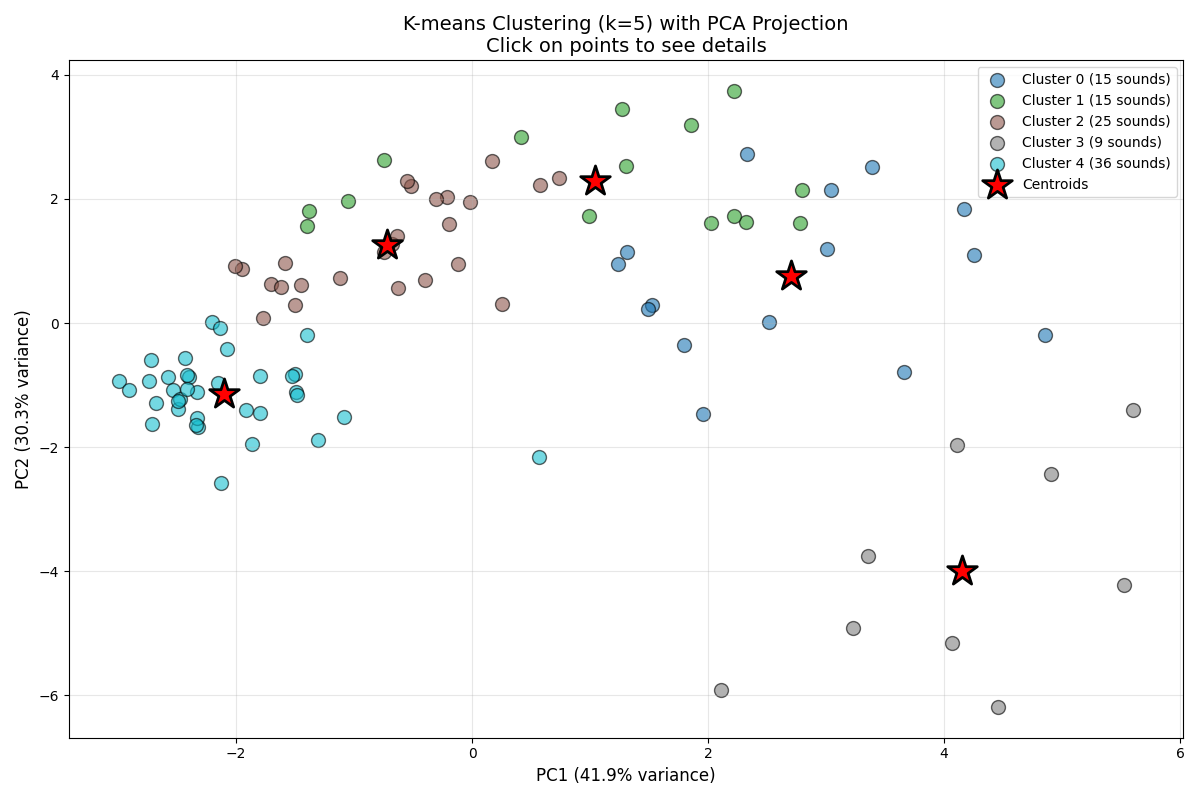

In [ ]:
# run textual clustering report
cluster_sounds('descSounds', nCluster=5, descInput=[0,1,2,3,4,5,6,7,8,9,10,11,12])

# interactive plot + click to play audio
_ = run_interactive_clustering(
    target_dir='descSounds',
    n_cluster=5,
    desc_input=[0,1,2,3,4,5,6,7,8,9,10,11,12],
    show_plot=True,
 )